GPU: True
2D Sine-Gordon方程设置:
定义域: t ∈ [0, 10], x1 ∈ [-7, 7], x2 ∈ [-7, 7]
精确解: u(x1,x2,t) = 4*arctan(exp(x1 + x2 - t))
初始条件点数: 400
边界条件点数: 1600
测试点数: 200000


100%|█████████████████████████████████| 6000/6000 [01:26<00:00, 69.71it/s, Iter=6000, Loss=1.88e-04]


Adam done!
Iter: 6001 Loss: 0.00018773559713736176
Iter: 6002 Loss: 0.00018773348710965365
Iter: 6003 Loss: 0.0001877335162134841
Iter: 6004 Loss: 0.00018773354531731457
Iter: 6005 Loss: 0.00018773363262880594
Iter: 6006 Loss: 0.0001877337199402973
Iter: 6007 Loss: 0.00018773370538838208
Iter: 6008 Loss: 0.00018773367628455162
Iter: 6009 Loss: 0.00018773357442114502
Iter: 6010 Loss: 0.0001877336617326364
Iter: 6011 Loss: 0.00018773357442114502
Iter: 6012 Loss: 0.00018773348710965365
Iter: 6013 Loss: 0.00018773348710965365
Iter: 6014 Loss: 0.0001877333561424166
Iter: 6015 Loss: 0.00018773332703858614
Iter: 6016 Loss: 0.0001877333124866709
Iter: 6017 Loss: 0.0001877333561424166
Iter: 6018 Loss: 0.00018773337069433182
Iter: 6019 Loss: 0.00018773339979816228
Iter: 6020 Loss: 0.00018773344345390797
Iter: 6021 Loss: 0.0001877335162134841
Iter: 6022 Loss: 0.00018773353076539934
Iter: 6023 Loss: 0.00018773358897306025
Iter: 6024 Loss: 0.00018773358897306025
Iter: 6025 Loss: 0.00018773357442114

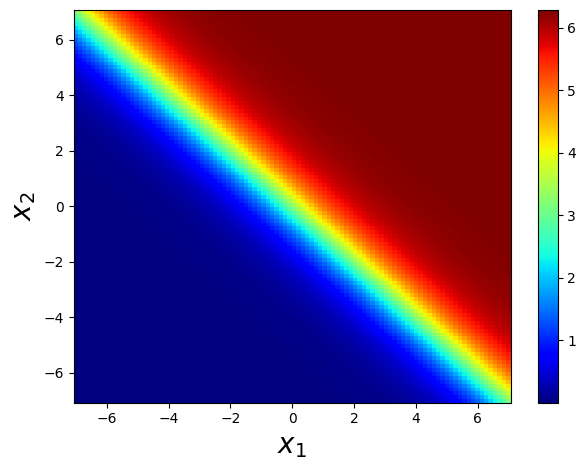

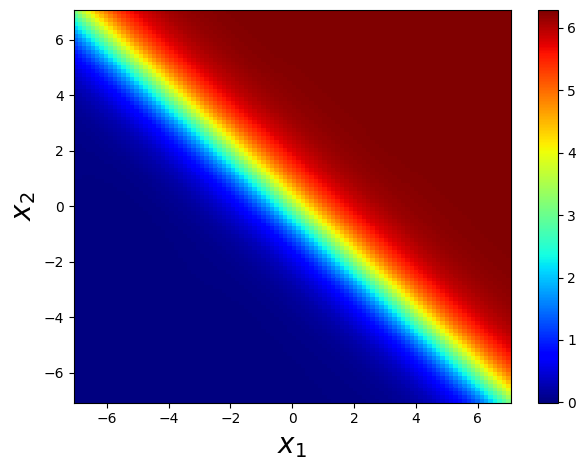

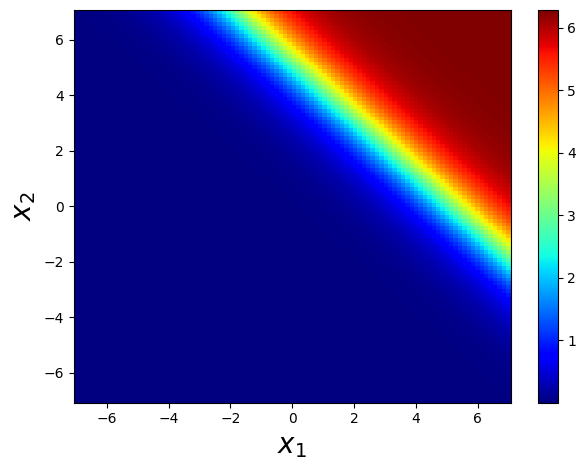

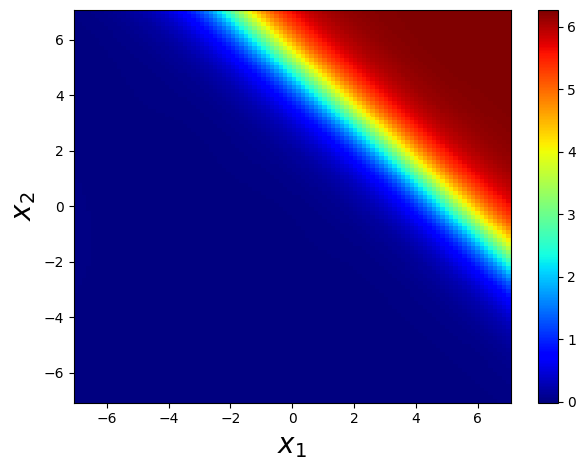

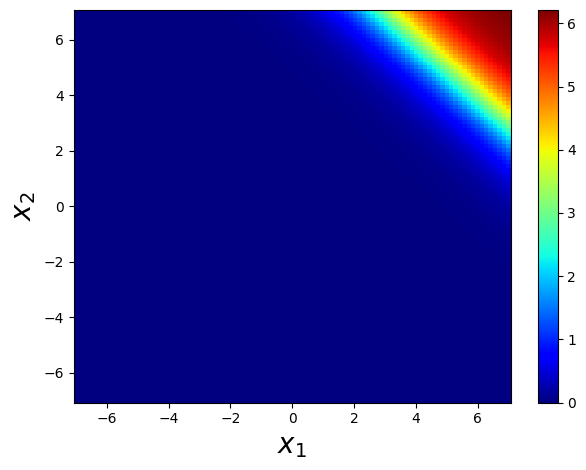

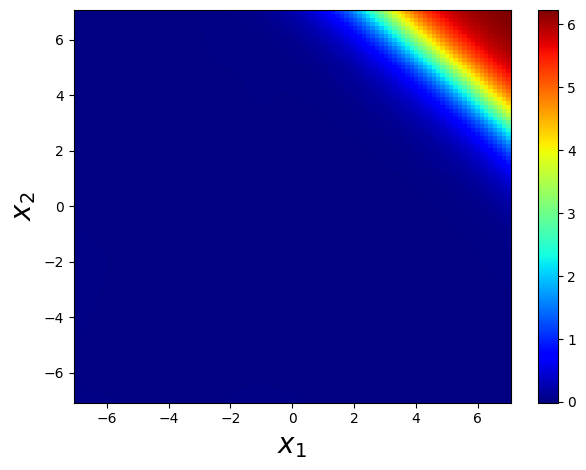


2. 绘制误差分布（3张图）


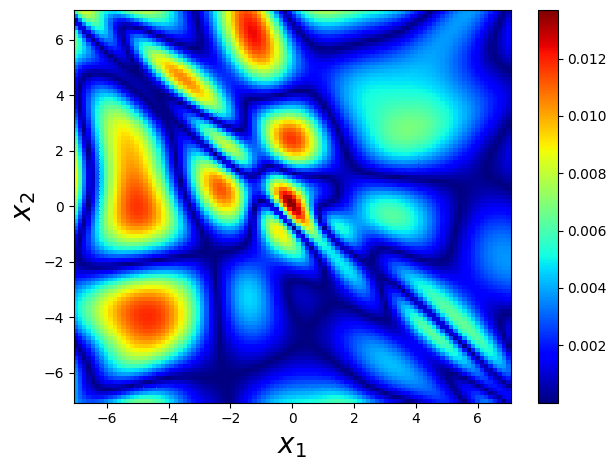

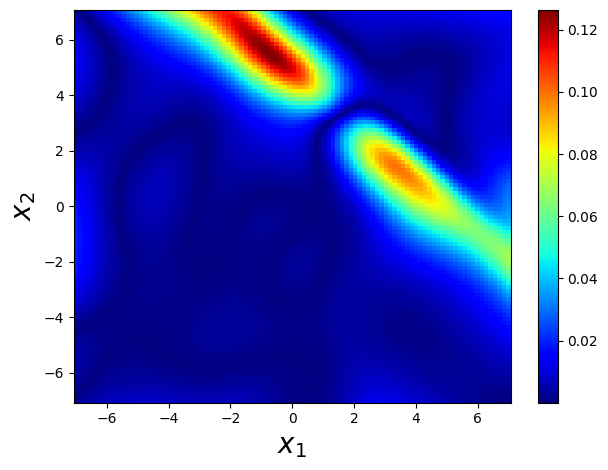

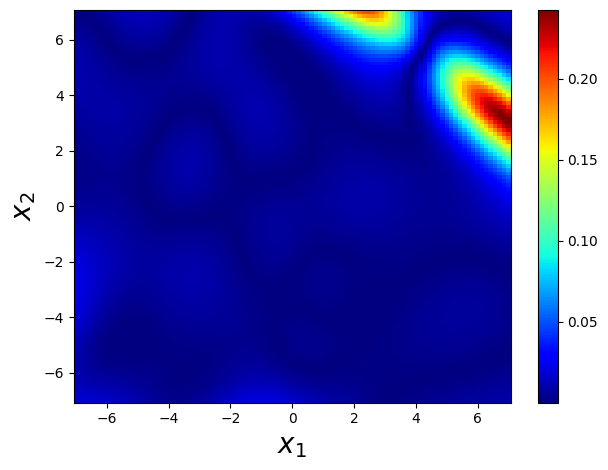


3. 绘制PDE残差分布（3张图）


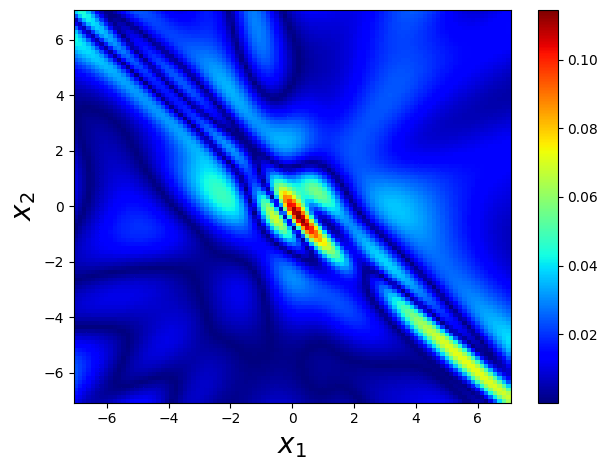

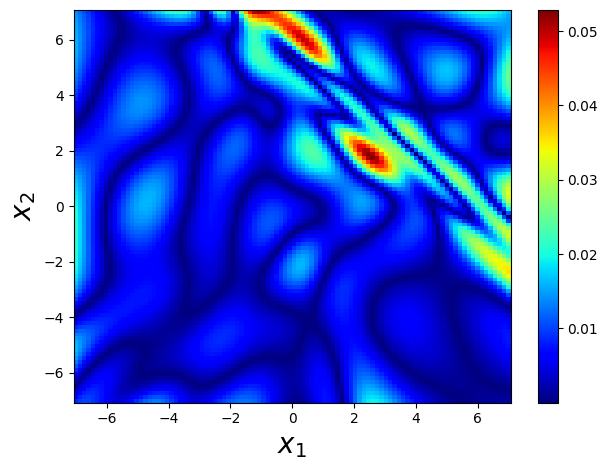

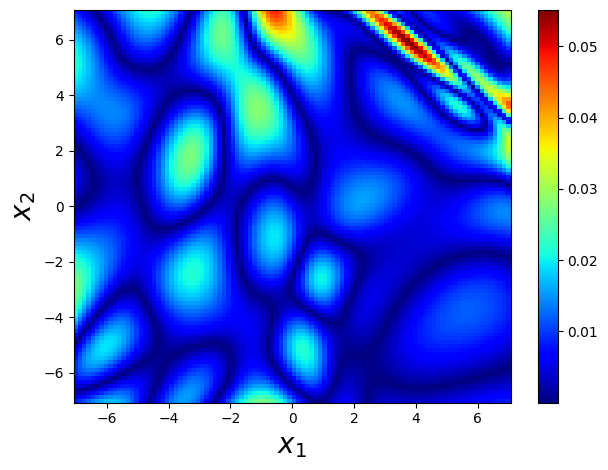


4. 绘制采样点分布（3张图）


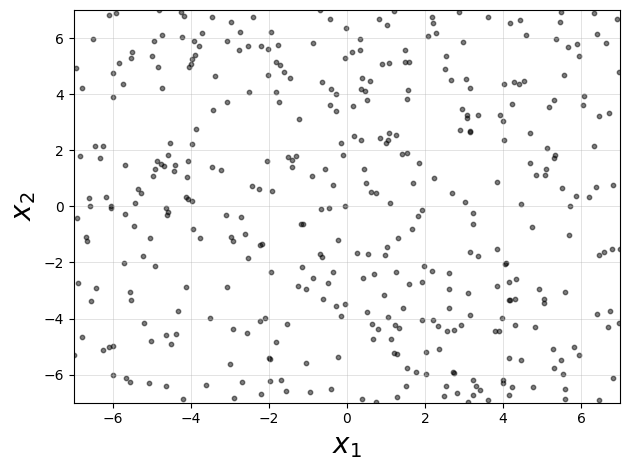

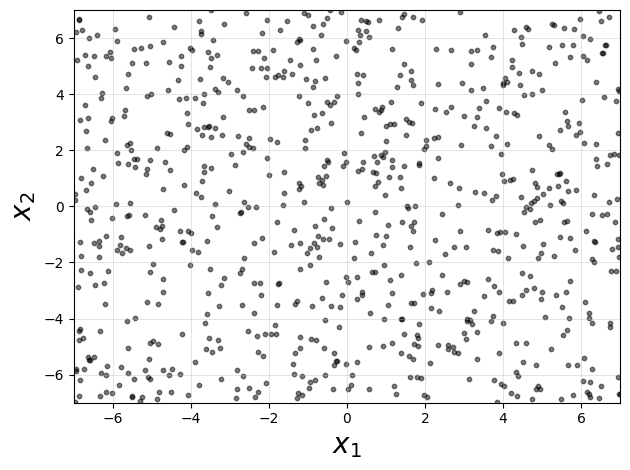

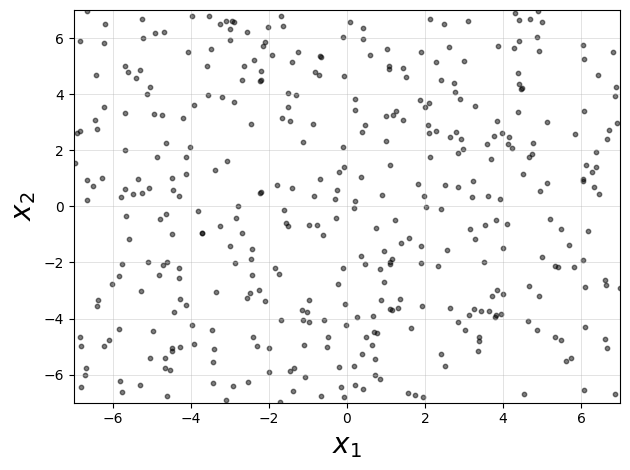


5. 计算L2相对误差
基础PINN L2相对误差: 9.769609e-03

6. 计算能量演化
正在计算PINN能量演化...
进度: 1/50, t=0.00, E=212.886490
进度: 6/50, t=1.02, E=205.356247
进度: 11/50, t=2.04, E=190.601242
进度: 16/50, t=3.06, E=174.905441
进度: 21/50, t=4.08, E=158.924942
进度: 26/50, t=5.10, E=142.724548
进度: 31/50, t=6.12, E=126.730110
进度: 36/50, t=7.14, E=110.765976
进度: 41/50, t=8.16, E=94.189232
进度: 46/50, t=9.18, E=77.121292
能量数据已保存到 pinn_energy_data.npz
能量数据已保存到 pinn_energy_data.txt

正在计算精确解能量演化进行对比...
正在计算精确解能量演化...
进度: 1/50, t=0.00, E=212.909645
进度: 6/50, t=1.02, E=205.719083
进度: 11/50, t=2.04, E=191.079115
进度: 16/50, t=3.06, E=174.985357
进度: 21/50, t=4.08, E=158.689319
进度: 26/50, t=5.10, E=142.366755
进度: 31/50, t=6.12, E=126.040741
进度: 36/50, t=7.14, E=109.714285
进度: 41/50, t=8.16, E=93.387822
进度: 46/50, t=9.18, E=77.061749
能量数据已保存到 exact_energy_data.npz
能量数据已保存到 exact_energy_data.txt

7. 绘制能量相对误差对比图


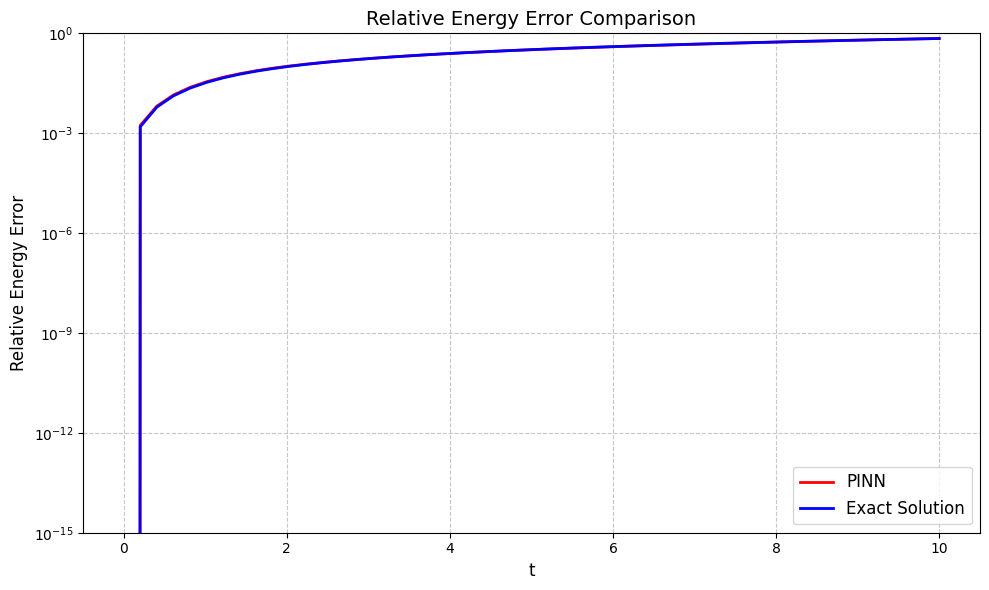


PINN能量统计:
初始能量 (t=0): 212.886490
最终能量 (t=10.0): 63.504990
能量变化: -70.170%
最大相对误差: 7.016955e-01
平均相对误差: 3.261943e-01

精确解能量统计:
初始能量 (t=0): 212.909645
最终能量 (t=10.0): 64.002683
能量变化: -69.939%
最大相对误差: 6.993904e-01
平均相对误差: 3.272310e-01

多时刻可视化完成！
总共生成图像：
- 精确解图像：3张（t=0, 5, 10）
- 预测解图像：3张（t=0, 5, 10）
- 误差分布图：3张（t=0, 5, 10）
- 残差分布图：3张（t=0, 5, 10）
- 采样点分布：3张（t=0, 5, 10）
- 能量相对误差对比图：1张
总计：16张图像


In [1]:
import os
import time
import numpy as np
import torch
from matplotlib import pyplot as plt, gridspec
from torch import nn
from torch.autograd import Variable
from tqdm import tqdm, trange
from pyDOE import lhs

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
seed = 1234
torch.set_default_dtype(torch.float)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

use_gpu = torch.cuda.is_available()
print('GPU:', use_gpu)


def random_fun(num):
    temp = torch.from_numpy(lb + (ub - lb) * lhs(3, num)).float()
    if use_gpu:
        temp = temp.cuda()
    return temp


def is_cuda(data):
    if use_gpu:
        data = data.cuda()
    return data


class FCNet(nn.Module):
    """FC Neural Network."""
    def __init__(self, layers, w_init=True, active=nn.Tanh()):
        super(FCNet, self).__init__()

        # Parameters
        self.depth = len(layers) - 1
        self.active = active

        # Layers list
        layer_list = list()
        for layer in range(self.depth - 1):
            layer_list.append(
                nn.Linear(layers[layer], layers[layer+1])
            )
            layer_list.append(active)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        # Net
        self.main = nn.Sequential(*layer_list)

        # Initialize parameters
        if w_init:
            self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1)
                m.bias.data.zero_()

    def forward(self, x):
        return self.main(x)

class Net2(nn.Module):
    def __init__(self, layers):
        super(Net2, self).__init__()
        self.layers = layers
        self.iter = 0
        self.activation = nn.Tanh()
        self.linear = nn.ModuleList([nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)])
        for i in range(len(layers) - 1):
            nn.init.xavier_normal_(self.linear[i].weight.data, gain=1.0)
            nn.init.zeros_(self.linear[i].bias.data)

    def forward(self, x):
        if not torch.is_tensor(x):
            x = torch.from_numpy(x)
        a = self.activation(self.linear[0](x))
        for i in range(1, len(self.layers) - 2):
            z = self.linear[i](a)
            a = self.activation(z)
        a = self.linear[-1](a)
        return a

class Net(nn.Module):
    """Deep Residual Learning for Image Recognition[arXiv:1512.03385]."""
    def __init__(self, backbone_layers, residual_layers):
        super(Net, self).__init__()

        # Check input and output
        if len(residual_layers) > 0 and backbone_layers[-2] != residual_layers[-1]:
            raise AssertionError("Output size of backbone net and residual net do not match!")
        self.iter = 0
        # layers
        self.res_layers = residual_layers
        self.backbone_layers = backbone_layers

        # Input layer
        self.input_layer = FCNet(self.backbone_layers[:2])

        # Backbone network.
        self.backbone = FCNet(self.backbone_layers[1:-1])

        # Residual network.
        self.residual = self._build_resnet()

        # Output layer
        self.output = FCNet(self.backbone_layers[-2:])

    def _build_resnet(self):
        """Build Res Connection."""
        if len(self.res_layers) == 0:
            return None
        layer_list = list()
        layer_list.append(nn.Linear(self.backbone_layers[1], self.res_layers[0]))
        layer_list.append(nn.Tanh())

        if len(self.res_layers) <= 1:
            return nn.Sequential(*layer_list)

        for layer in range(1, len(self.res_layers)-1):
            layer_list.append(nn.Linear(self.res_layers[layer], self.res_layers[layer+1]))
            layer_list.append(nn.Tanh())

        return nn.Sequential(*layer_list)

    def forward(self, x):
        x = self.input_layer(x)
        b = self.backbone(x)

        if self.residual is not None:
            r = self.residual(x)
            x = r + b
        x = x + b

        return self.output(x)


class Model:
    def __init__(self, net, x_bc,
                 u_bc,
                 x_ic,
                 u_ic,
                 x_ic_t,
                 u_ic_t,
                 x_f_loss_fun,
                 x_test, x_test_exact
                 ):

        self.x_ic_s = None
        self.x_bc_s = None
        self.x_ict_s = None
        self.x_f_s = None
        self.s_collect = []

        self.optimizer_LBGFS = None
        self.net = net

        self.x_bc = x_bc
        self.u_bc = u_bc

        self.x_ic = x_ic
        self.u_ic = u_ic
        
        self.x_ic_t = x_ic_t
        self.u_ic_t = u_ic_t

        self.x_f_N = None
        self.x_f_M = None

        self.x_f_loss_fun = x_f_loss_fun

        self.x_test = x_test
        self.x_test_exact = x_test_exact

        self.start_loss_collect = False
        self.x_label_loss_collect = []
        self.x_f_loss_collect = []
        self.x_test_estimate_collect = []

    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        return self.train_U(x)

    def likelihood_loss(self, loss_e, loss_ic, loss_bc, loss_ic_t):
        loss = torch.exp(-self.x_f_s) * loss_e.detach() + self.x_f_s \
               + torch.exp(-self.x_ic_s) * loss_ic.detach() + self.x_ic_s \
               + torch.exp(-self.x_bc_s) * loss_bc.detach() + self.x_bc_s \
               + torch.exp(-self.x_ict_s) * loss_ic_t.detach() + self.x_ict_s
        return loss

    def true_loss(self, loss_e, loss_ic, loss_bc, loss_ic_t):
        return torch.exp(-self.x_f_s.detach()) * loss_e + torch.exp(-self.x_ic_s.detach()) * loss_ic + torch.exp(
            -self.x_bc_s.detach()) * loss_bc + torch.exp(-self.x_ict_s.detach()) * loss_ic_t

    # compute backward loss
    def epoch_loss(self):
        x_f = torch.cat((self.x_f_N, self.x_f_M), dim=0)
        loss_equation_u= self.x_f_loss_fun(x_f, self.train_U)
        loss_equation = torch.mean(loss_equation_u ** 2) 

        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)

        # 初始时间导数条件
        x = Variable(self.x_ic_t, requires_grad=True)
        u0 = self.train_U(x)
        d = torch.autograd.grad(u0, x, grad_outputs=torch.ones_like(u0), create_graph=True)
        u0_t = d[0][:, 0].unsqueeze(-1)
        loss_ic_t = torch.mean((u0_t - self.u_ic_t) ** 2)

        return loss_equation, loss_ic, loss_bc, loss_ic_t

    # compute backward loss

    def LBGFS_epoch_loss(self):
        self.optimizer_LBGFS.zero_grad()
        x_f = torch.cat((self.x_f_N, self.x_f_M), dim=0)
        loss_equation_u= self.x_f_loss_fun(x_f, self.train_U)
        loss_equation = torch.mean(loss_equation_u ** 2) 

        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)

        x = Variable(self.x_ic_t, requires_grad=True)
        u0 = self.train_U(x)
        d = torch.autograd.grad(u0, x, grad_outputs=torch.ones_like(u0), create_graph=True)
        u0_t = d[0][:, 0].unsqueeze(-1)
        loss_ic_t = torch.mean((u0_t - self.u_ic_t) ** 2)

        loss = self.true_loss(loss_equation, loss_ic, loss_bc, loss_ic_t)
        loss.backward()
        self.net.iter += 1
        print('Iter:', self.net.iter, 'Loss:', loss.item())
        
        # 保存PINN损失历史
        if not hasattr(self, 'pinn_loss_history'):
            self.pinn_loss_history = []
        self.pinn_loss_history.append(loss.item())
        
        return loss

    def evaluate(self):
        pred = self.train_U(self.x_test).cpu().detach().numpy()
        exact = self.x_test_exact.cpu().detach().numpy()
        exact = exact.flatten()[:, None]
        error = np.linalg.norm(pred - exact, 2) / np.linalg.norm(exact, 2)
        return error

    def run_baseline(self):
        # 初始化损失历史记录
        self.pinn_loss_history = []
        
        optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
        self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                 max_iter=1)  # 设置为1，手动控制迭代
        pbar = trange(adam_iter, ncols=100)
        for i in pbar:
            optimizer_adam.zero_grad()
            loss_e, loss_ic, loss_bc, loss_ic_t = self.epoch_loss()
            loss = self.true_loss(loss_e, loss_ic, loss_bc, loss_ic_t)
            loss.backward()
            optimizer_adam.step()
            self.net.iter += 1
            
            # 记录Adam损失
            self.pinn_loss_history.append(loss.item())
            
            pbar.set_postfix({'Iter': self.net.iter,
                              'Loss': '{0:.2e}'.format(loss.item())
                              })

        print('Adam done!')
        
        # 手动运行LBFGS确保完整2000次
        for i in range(lbgfs_iter):
            self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
        print('LBFGS done!')

        error = self.evaluate()
        print('Test_L2error:', '{0:.2e}'.format(error))
        
        # 保存损失历史
        np.save('pinn_loss_history.npy', np.array(self.pinn_loss_history))


    def run_AM(self):
        for move_count in range(AM_count):
            self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                     max_iter=lbgfs_iter)
            optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
            pbar = trange(adam_iter, ncols=100)

            for i in pbar:
                optimizer_adam.zero_grad()
                loss_e, loss_ic, loss_bc, loss_ic_t = self.epoch_loss()
                loss = self.true_loss(loss_e, loss_ic, loss_bc, loss_ic_t)
                loss.backward()
                self.net.iter += 1
                optimizer_adam.step()
                pbar.set_postfix({'Iter': self.net.iter,
                                  'Loss': '{0:.2e}'.format(loss.item())
                                  })

            print('Adam done!')
            self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
            print('LBGFS done!')

            error = self.evaluate()
            print('change_counts', move_count, 'Test_L2error:', '{0:.2e}'.format(error))
            self.x_test_estimate_collect.append([move_count, '{0:.2e}'.format(error)])

            if AM_type == 0:
                x_init = random_fun(100000)
                loss_eq_u = self.x_f_loss_fun(x_init, self.train_U)
                x_init_residual = abs(loss_eq_u) 
                x_init_residual = x_init_residual.cpu().detach().numpy()
                err_eq = np.power(x_init_residual, AM_K) / np.power(x_init_residual, AM_K).mean()
                err_eq_normalized = (err_eq / sum(err_eq))[:, 0]
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=err_eq_normalized)
                self.x_f_M = x_init[X_ids]

            elif AM_type == 1:
                x_init = random_fun(100000)
                x = Variable(x_init, requires_grad=True)
                u = self.train_U(x)
                dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
                grad_norm = torch.norm(dx, dim=1).cpu().detach().numpy()
                err_dx = np.power(grad_norm, AM_K) / np.power(grad_norm, AM_K).mean()
                p = (err_dx / sum(err_dx))
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=p)
                self.x_f_M = x_init[X_ids]
            elif AM_type == 2:
                x_init = random_fun(100000)
                x = Variable(x_init, requires_grad=True)
                u = self.train_U(x)
                dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
                grad_x1 = dx[:, [0]].squeeze()
                grad_x2 = dx[:, [1]].squeeze()
                grad_x3 = dx[:, [2]].squeeze()
                dx = torch.sqrt(1 + grad_x1 ** 2 + grad_x2 ** 2 + grad_x3 ** 2).cpu().detach().numpy()
                err_dx = np.power(dx, AM_K) / np.power(dx, AM_K).mean()
                p = (err_dx / sum(err_dx))
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=p)
                self.x_f_M = x_init[X_ids]

    def run_AM_AW1(self):
        self.x_f_s = nn.Parameter(self.x_f_s, requires_grad=True)
        self.x_ic_s = nn.Parameter(self.x_ic_s, requires_grad=True)
        self.x_bc_s = nn.Parameter(self.x_bc_s, requires_grad=True)
        self.x_ict_s = nn.Parameter(self.x_ict_s, requires_grad=True)

        for move_count in range(AM_count):
            self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                     max_iter=lbgfs_iter)
            optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
            optimizer_adam_weight = torch.optim.Adam([self.x_f_s] + [self.x_ic_s] + [self.x_bc_s] + [self.x_ict_s],
                                                     lr=AW_lr)

            pbar = trange(adam_iter, ncols=100)
            for i in pbar:
                self.s_collect.append([self.net.iter, self.x_f_s.item(), self.x_ic_s.item(), self.x_bc_s.item(), self.x_ict_s.item()])

                loss_e, loss_ic, loss_bc, loss_ic_t = self.epoch_loss()

                optimizer_adam.zero_grad()
                loss = self.true_loss(loss_e, loss_ic, loss_bc, loss_ic_t)
                loss.backward()
                optimizer_adam.step()
                self.net.iter += 1
                pbar.set_postfix({'Iter': self.net.iter,
                                  'Loss': '{0:.2e}'.format(loss.item())
                                  })

                optimizer_adam_weight.zero_grad()
                loss = self.likelihood_loss(loss_e, loss_ic, loss_bc, loss_ic_t)
                loss.backward()
                optimizer_adam_weight.step()

            print('Adam done!')
            self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
            print('LBGFS done!')

            error = self.evaluate()
            print('change_counts', move_count, 'Test_L2error:', '{0:.2e}'.format(error))
            self.x_test_estimate_collect.append([move_count, '{0:.2e}'.format(error)])

            if AM_type == 0:
                x_init = random_fun(100000)
                loss_eq_u = self.x_f_loss_fun(x_init, self.train_U)
                x_init_residual = abs(loss_eq_u) 
                x_init_residual = x_init_residual.cpu().detach().numpy()
                err_eq = np.power(x_init_residual, AM_K) / np.power(x_init_residual, AM_K).mean()
                err_eq_normalized = (err_eq / sum(err_eq))[:, 0]
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=err_eq_normalized)
                self.x_f_M = x_init[X_ids]

            elif AM_type == 1:
                x_init = random_fun(100000)
                x = Variable(x_init, requires_grad=True)
                u = self.train_U(x)
                dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
                grad_norm = torch.norm(dx, dim=1).cpu().detach().numpy()
                err_dx = np.power(grad_norm, AM_K) / np.power(grad_norm, AM_K).mean()
                p = (err_dx / sum(err_dx))
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=p)
                self.x_f_M = x_init[X_ids]
            elif AM_type == 2:
                x_init = random_fun(100000)
                x = Variable(x_init, requires_grad=True)
                u = self.train_U(x)
                dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
                grad_x1 = dx[:, [0]].squeeze()
                grad_x2 = dx[:, [1]].squeeze()
                grad_x3 = dx[:, [2]].squeeze()
                dx = torch.sqrt(1 + grad_x1 ** 2 + grad_x2 ** 2 + grad_x3 ** 2).cpu().detach().numpy()
                err_dx = np.power(dx, AM_K) / np.power(dx, AM_K).mean()
                p = (err_dx / sum(err_dx))
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=p)
                self.x_f_M = x_init[X_ids]

    def train(self):

        self.x_f_N = random_fun(N)
        self.x_f_M = random_fun(M)

        self.x_f_s = is_cuda(torch.tensor(0.).float())
        self.x_ic_s = is_cuda(torch.tensor(0.).float())
        self.x_bc_s = is_cuda(torch.tensor(0.).float())
        self.x_ict_s = is_cuda(torch.tensor(0.).float())

        start_time = time.time()
        if model_type == 0:
            self.run_baseline()
        elif model_type == 1:
            self.run_AM()
        elif model_type == 2:
            self.run_AM_AW1()
        elapsed = time.time() - start_time

        print('Training time: %.2f' % elapsed)


def x_f_loss_fun(x, train_U):
    """2D Sine-Gordon方程的PDE损失函数"""
    if not x.requires_grad:
        x = Variable(x, requires_grad=True)
    u = train_U(x)
    
    # 计算一阶导数
    d = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)
    u_t = d[0][:, 0].unsqueeze(-1)    # 时间导数
    u_x1 = d[0][:, 1].unsqueeze(-1)   # x1方向导数
    u_x2 = d[0][:, 2].unsqueeze(-1)   # x2方向导数
    
    # 计算二阶导数
    u_tt = torch.autograd.grad(u_t, x, grad_outputs=torch.ones_like(u_t), create_graph=True)[0][:, [0]]
    u_x1x1 = torch.autograd.grad(u_x1, x, grad_outputs=torch.ones_like(u_x1), create_graph=True)[0][:, [1]]
    u_x2x2 = torch.autograd.grad(u_x2, x, grad_outputs=torch.ones_like(u_x2), create_graph=True)[0][:, [2]]
    
    # 2D Sine-Gordon方程: u_tt - u_x1x1 - u_x2x2 + sin(u) = 0
    f = u_tt - u_x1x1 - u_x2x2 + torch.sin(u)
    
    return f


def exact_u(x):
    """2D Sine-Gordon方程的精确解"""
    t = x[:, [0]]   # 时间 
    x1 = x[:, [1]]  # 空间坐标x1
    x2 = x[:, [2]]  # 空间坐标x2
    
    # 使用图片中给出的精确解: u(x1, x2, t) = 4*arctan(exp(x1 + x2 - t))
    u = 4 * np.arctan(np.exp(x1 + x2 - t))
    return u


def exact_u_t(x):
    """2D Sine-Gordon方程精确解的时间导数"""
    t = x[:, [0]]
    x1 = x[:, [1]]
    x2 = x[:, [2]]
    
    # u_t = -4 * exp(x1 + x2 - t) / (1 + exp^2(x1 + x2 - t))
    exp_term = np.exp(x1 + x2 - t)
    u_t = -4 * exp_term / (1 + exp_term**2)
    return u_t
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import dblquad
import torch

def compute_energy_at_time_pinn(model, t_value, x1_range=(-7, 7), x2_range=(-7, 7), num_points=100):
    """
    计算PINN模型在特定时刻t的能量
    使用更密集的网格点以提高积分精度
    """
    # 创建空间网格
    x1_grid = np.linspace(x1_range[0], x1_range[1], num_points)
    x2_grid = np.linspace(x2_range[0], x2_range[1], num_points)
    X1, X2 = np.meshgrid(x1_grid, x2_grid, indexing='ij')
    
    # 创建时空点 (t, x1, x2)
    t_grid = t_value * np.ones_like(X1)
    points = np.stack([t_grid.flatten(), X1.flatten(), X2.flatten()], axis=1)
    points_tensor = is_cuda(torch.from_numpy(points).float())
    
    # 计算 u 及其导数
    points_tensor.requires_grad_(True)
    u = model.train_U(points_tensor)
    
    # 计算一阶导数
    grad_u = torch.autograd.grad(u, points_tensor, 
                                grad_outputs=torch.ones_like(u), 
                                create_graph=True)[0]
    
    u_t = grad_u[:, 0]   # ∂u/∂t
    u_x1 = grad_u[:, 1]  # ∂u/∂x1  
    u_x2 = grad_u[:, 2]  # ∂u/∂x2
    
    # 计算能量密度：E = 0.5 * (u_t² + u_x1² + u_x2² + 2(1 - cos(u)))
    energy_density = 0.5 * (u_t**2 + u_x1**2 + u_x2**2 + 2*(1 - torch.cos(u.squeeze())))
    
    # 重塑为网格形状
    energy_density = energy_density.reshape(num_points, num_points)
    
    # 数值积分计算总能量 (使用梯形法则)
    dx1 = (x1_range[1] - x1_range[0]) / (num_points - 1)
    dx2 = (x2_range[1] - x2_range[0]) / (num_points - 1)
    
    total_energy = torch.trapz(torch.trapz(energy_density, dim=1), dim=0) * dx1 * dx2
    
    return total_energy.cpu().detach().numpy().item()

def compute_energy_evolution_pinn(model, t_array):
    """
    计算PINN能量随时间的演化，并计算相对误差
    """
    energies = []
    print("正在计算PINN能量演化...")
    
    for i, t_val in enumerate(t_array):
        energy = compute_energy_at_time_pinn(model, t_val)
        energies.append(energy)
        if i % 5 == 0:  # 每5个点打印一次进度
            print(f"进度: {i+1}/{len(t_array)}, t={t_val:.2f}, E={energy:.6f}")
    
    energies = np.array(energies)
    E0 = energies[0]  # 初始能量
    
    # 计算相对误差
    rel_errors = np.abs(energies - E0) / E0
    
    return energies, rel_errors, E0
def compute_exact_energy_evolution(t_array):
    """
    计算精确解的能量演化作为参考
    """
    def u_exact(x1, x2, t):
        return 4 * np.arctan(np.exp(x1 + x2 - t))
    
    def u_t_exact(x1, x2, t):
        exp_term = np.exp(x1 + x2 - t)
        return -4 * exp_term / (1 + exp_term**2)
    
    def u_x1_exact(x1, x2, t):
        exp_term = np.exp(x1 + x2 - t)
        return 4 * exp_term / (1 + exp_term**2)
    
    def u_x2_exact(x1, x2, t):
        return u_x1_exact(x1, x2, t)  # 对称性
    
    def energy_density(x1, x2, t):
        u = u_exact(x1, x2, t)
        ut = u_t_exact(x1, x2, t)
        ux1 = u_x1_exact(x1, x2, t)
        ux2 = u_x2_exact(x1, x2, t)
        return 0.5 * (ut**2 + ux1**2 + ux2**2 + 2*(1 - np.cos(u)))
    
    def compute_energy(t):
        return dblquad(energy_density, -7, 7, lambda x: -7, lambda x: 7, args=(t,))[0]
    
    print("正在计算精确解能量演化...")
    energies = []
    for i, t in enumerate(t_array):
        E_t = compute_energy(t)
        energies.append(E_t)
        if i % 5 == 0:
            print(f"进度: {i+1}/{len(t_array)}, t={t:.2f}, E={E_t:.6f}")
    
    energies = np.array(energies)
    E0 = energies[0]
    rel_errors = np.abs(energies - E0) / E0
    
    return energies, rel_errors, E0

def plot_energy_comparison(t_array, pinn_energies, pinn_rel_errors, exact_energies=None, exact_rel_errors=None):
    """
    绘制能量相对误差对比图
    """
    plt.figure(figsize=(10, 6))
    
    # 绘制PINN的相对误差
    plt.semilogy(t_array, pinn_rel_errors, 'r-', linewidth=2, label='PINN')
    
    # 如果有精确解数据，也绘制出来
    if exact_rel_errors is not None:
        plt.semilogy(t_array, exact_rel_errors, 'b-', linewidth=2, label='Exact Solution')
    
    # 设置图表格式
    plt.title('Relative Energy Error Comparison', fontsize=14)
    plt.xlabel('t', fontsize=12)
    plt.ylabel('Relative Energy Error', fontsize=12)
    plt.xticks(np.arange(0, int(t_array[-1])+1, 2))
    
    # 动态设置y轴刻度
    min_error = min(np.min(pinn_rel_errors), np.min(exact_rel_errors) if exact_rel_errors is not None else np.inf)
    max_error = max(np.max(pinn_rel_errors), np.max(exact_rel_errors) if exact_rel_errors is not None else 0)
    
    if min_error < 1e-12:
        plt.yticks([1e-15, 1e-12, 1e-9, 1e-6, 1e-3, 1e-0])
    elif min_error < 1e-9:
        plt.yticks([1e-12, 1e-9, 1e-6, 1e-3, 1e-0])
    else:
        plt.yticks([1e-9, 1e-6, 1e-3, 1e-0])
    
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

def save_energy_data(filename, t_array, energies, rel_errors, E0, method_name="PINN"):
    """
    保存能量数据到文件
    """
    data = {
        'time': t_array,
        'energies': energies, 
        'relative_errors': rel_errors,
        'initial_energy': E0,
        'method': method_name
    }
    np.savez(filename, **data)
    print(f"能量数据已保存到 {filename}")
    
    # 同时保存为文本文件便于查看
    txt_filename = filename.replace('.npz', '.txt')
    with open(txt_filename, 'w') as f:
        f.write(f"# {method_name} Energy Evolution Data\n")
        f.write(f"# Initial Energy: {E0:.10e}\n")
        f.write("# Time\tEnergy\tRelative_Error\n")
        for t, E, rel_err in zip(t_array, energies, rel_errors):
            f.write(f"{t:.6f}\t{E:.10e}\t{rel_err:.10e}\n")
    print(f"能量数据已保存到 {txt_filename}")
    

def draw_exact_multi_time(time_indices=[0, 10, 19]):
    """
    绘制多个时刻的精确解与PINN解对比
    time_indices对应t=0, t=5, t=10时刻
    """
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test_np = x_test_exact.cpu().detach().numpy()
    u_test_np = u_test_np.flatten()[:, None]
    
    # 重塑为3D数组：(时间, x1, x2)
    e_u = np.reshape(u_test_np, (len(t), len(x1), len(x2)))
    pred_u = np.reshape(predict_np, (len(t), len(x1), len(x2)))
    
    XX1, XX2 = np.meshgrid(x1, x2, indexing='ij')
    
    # 对应的时刻值
    time_values = [t[idx] for idx in time_indices]
    time_labels = ['t=0', 't=5', 't=10']
    
    for i, (time_idx, time_val, time_label) in enumerate(zip(time_indices, time_values, time_labels)):
        # 精确解
        plt.figure()
        e = e_u[time_idx, :, :]
        plt.pcolor(XX1, XX2, e, cmap='jet', shading='auto')
        plt.colorbar()
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)
        plt.tight_layout()
        plt.show()
        
        # PINN预测解
        plt.figure()
        pred = pred_u[time_idx, :, :]
        plt.pcolor(XX1, XX2, pred, cmap='jet', shading='auto')
        plt.colorbar()
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)
        plt.tight_layout()
        plt.show()

def draw_error_multi_time(time_indices=[0, 10, 19]):
    """绘制多个时刻的误差分布图"""
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test_np = x_test_exact.cpu().detach().numpy()
    u_test_np = u_test_np.flatten()[:, None]
    error_u = np.abs(predict_np - u_test_np)
    
    error_u = np.reshape(error_u, (len(t), len(x1), len(x2)))
    X1, X2 = np.meshgrid(x1, x2, indexing='ij')
    
    # 对应的时刻值和标签
    time_values = [t[idx] for idx in time_indices]
    time_labels = ['t=0', 't=5', 't=10']
    
    for i, (time_idx, time_val, time_label) in enumerate(zip(time_indices, time_values, time_labels)):
        plt.figure()
        plt.pcolor(X1, X2, error_u[time_idx, :, :], cmap='jet', shading='auto')
        plt.colorbar()
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)
        plt.tight_layout()
        plt.show()

def draw_residual_multi_time(time_indices=[0, 10, 19]):
    """绘制多个时刻的PDE残差分布图"""
    f_u = x_f_loss_fun(x_test, model.train_U)
    f_u = f_u.cpu().detach().numpy()

    residual = np.reshape(abs(f_u), (len(t), len(x1), len(x2)))
    X1, X2 = np.meshgrid(x1, x2, indexing='ij')
    
    # 对应的时刻值和标签
    time_values = [t[idx] for idx in time_indices]
    time_labels = ['t=0', 't=5', 't=10']
    
    for i, (time_idx, time_val, time_label) in enumerate(zip(time_indices, time_values, time_labels)):
        plt.figure()
        plt.pcolor(X1, X2, residual[time_idx, :, :], cmap='jet', shading='auto')
        plt.colorbar()
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)
        plt.tight_layout()
        plt.show()

def draw_sampling_points_2d_multi_time(model, time_indices=[0, 10, 19]):
    """
    绘制多个时刻的采样点分布图
    蓝色点：自适应采样点 (x_f_M)
    黑色点：固定采样点 (x_f_N)
    """
    if not (hasattr(model, 'x_f_M') and hasattr(model, 'x_f_N')):
        print("模型没有采样点数据")
        return
    
    # 获取采样点
    x_f_M_np = model.x_f_M.cpu().detach().numpy()
    x_f_N_np = model.x_f_N.cpu().detach().numpy()
    
    time_values = [t[idx] for idx in time_indices]
    time_labels = ['t=0', 't=5', 't=10']
    
    for i, (time_idx, target_time, time_label) in enumerate(zip(time_indices, time_values, time_labels)):
        time_tolerance = (t[-1] - t[0]) / 20
        
        # 过滤自适应采样点
        M_mask = np.abs(x_f_M_np[:, 0] - target_time) < time_tolerance
        M_points_at_time = x_f_M_np[M_mask]
        
        # 过滤固定采样点
        N_mask = np.abs(x_f_N_np[:, 0] - target_time) < time_tolerance
        N_points_at_time = x_f_N_np[N_mask]
        
        plt.figure()
        
        # 绘制固定采样点 (黑色)
        if len(N_points_at_time) > 0:
            plt.scatter(N_points_at_time[:, 1], N_points_at_time[:, 2], 
                       c='black', s=10, alpha=0.5)
        
        # 绘制自适应采样点 (蓝色)  
        if len(M_points_at_time) > 0:
            plt.scatter(M_points_at_time[:, 1], M_points_at_time[:, 2], 
                       c='black', s=10, alpha=0.5)
        
        plt.xlim(lb[1], ub[1])
        plt.ylim(lb[2], ub[2])
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)
        plt.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
        plt.tight_layout()
        plt.show()

def draw_all_multi_time():
    """
    修改后的绘制所有时刻的所有图像函数
    """
    print("=" * 80)
    print("基础PINN 多时刻可视化 (t=0, t=0.5, t=1)")
    print("=" * 80)
    
    # 确定时间索引：t=0 (idx=0), t=0.5 (idx=10), t=1 (idx=19)
    time_indices = [0, 10, 19]
    time_values = [t[idx] for idx in time_indices]
    print(f"选择的时刻：t={time_values[0]:.1f} (idx={time_indices[0]}), t={time_values[1]:.1f} (idx={time_indices[1]}), t={time_values[2]:.1f} (idx={time_indices[2]})")
    
    # 1. 绘制精确解与预测解（每个时刻2张图）
    print("\n1. 绘制精确解与预测解（3个时刻 × 2张图 = 6张图）")
    draw_exact_multi_time(time_indices)
    
    # 2. 绘制误差分布（每个时刻1张图）
    print("\n2. 绘制误差分布（3张图）")
    draw_error_multi_time(time_indices)
    
    # 3. 绘制PDE残差（每个时刻1张图）
    print("\n3. 绘制PDE残差分布（3张图）")
    draw_residual_multi_time(time_indices)
    
    # 4. 绘制采样点分布（每个时刻1张图）
    print("\n4. 绘制采样点分布（3张图）")
    draw_sampling_points_2d_multi_time(model, time_indices)
    
    # 5. 计算并显示L2误差
    print("\n5. 计算L2相对误差")
    error = model.evaluate()
    print(f'基础PINN L2相对误差: {error:.6e}')
    
    # 6. 计算能量演化（修改后的部分）
    print("\n6. 计算能量演化")
    t_energy = np.linspace(0, 10, 50)  # 50个时间点，减少计算量
    
    # 计算PINN能量演化
    pinn_energies, pinn_rel_errors, pinn_E0 = compute_energy_evolution_pinn(model, t_energy)
    
    # 保存PINN能量数据
    save_energy_data('pinn_energy_data.npz', t_energy, pinn_energies, pinn_rel_errors, pinn_E0, 'PINN')
    
    # 可选：计算精确解能量演化进行对比（时间较长，可注释掉）
    print("\n正在计算精确解能量演化进行对比...")
    exact_energies, exact_rel_errors, exact_E0 = compute_exact_energy_evolution(t_energy)
    save_energy_data('exact_energy_data.npz', t_energy, exact_energies, exact_rel_errors, exact_E0, 'Exact')
    
    # 绘制能量相对误差对比图
    print("\n7. 绘制能量相对误差对比图")
    plot_energy_comparison(t_energy, pinn_energies, pinn_rel_errors, exact_energies, exact_rel_errors)
    
    # 显示能量统计信息
    print(f"\nPINN能量统计:")
    print(f"初始能量 (t=0): {pinn_E0:.6f}")
    print(f"最终能量 (t={t_energy[-1]}): {pinn_energies[-1]:.6f}")
    print(f"能量变化: {((pinn_energies[-1] - pinn_E0)/pinn_E0*100):.3f}%")
    print(f"最大相对误差: {np.max(pinn_rel_errors):.6e}")
    print(f"平均相对误差: {np.mean(pinn_rel_errors):.6e}")
    
    if exact_energies is not None:
        print(f"\n精确解能量统计:")
        print(f"初始能量 (t=0): {exact_E0:.6f}")
        print(f"最终能量 (t={t_energy[-1]}): {exact_energies[-1]:.6f}")
        print(f"能量变化: {((exact_energies[-1] - exact_E0)/exact_E0*100):.3f}%")
        print(f"最大相对误差: {np.max(exact_rel_errors):.6e}")
        print(f"平均相对误差: {np.mean(exact_rel_errors):.6e}")
    
    print("\n" + "=" * 80)
    print("多时刻可视化完成！")
    print("总共生成图像：")
    print("- 精确解图像：3张（t=0, 5, 10）")
    print("- 预测解图像：3张（t=0, 5, 10）")
    print("- 误差分布图：3张（t=0, 5, 10）")
    print("- 残差分布图：3张（t=0, 5, 10）")
    print("- 采样点分布：3张（t=0, 5, 10）")
    print("- 能量相对误差对比图：1张")
    print("总计：16张图像")
    print("=" * 80)

# ================================================================
# 在你的原始PINN代码最后，替换这部分：
# ================================================================

if __name__ == '__main__':
    # ... 你的原始代码保持不变，直到这里 ...
    
    # 原来的代码:
    # lb = np.array([0.0, -7.0, -7.0])
    # ub = np.array([1.0, 7.0, 7.0])
    # ... 所有设置和训练代码保持不变 ...
    
    # 2D Sine-Gordon方程的定义域: (x,t) ∈ [-7,7]² × [0,+∞)
    # 这里我们取有限时间域 [0,1]
    lb = np.array([0.0, -7.0, -7.0])  # [t_min, x1_min, x2_min]
    ub = np.array([10.0, 7.0, 7.0])    # [t_max, x1_max, x2_max]

    layers = [3, 20, 20, 20, 20, 20, 1]

    net = is_cuda(Net2(layers))
    N = 4000
    M = 4000
    Nbc = 400
    Nic = 400

    adam_iter, lbgfs_iter = 6000, 2000  # 修改为6000次Adam + 2000次LBFGS
    adam_lr, lbgfs_lr = 0.001, 0.005

    model_type = 0  # 0:baseline  1:AM  2:AM_AW

    AM_type = 0  # 0:RAM  1:WAM
    AM_K = 2
    AM_count = 1

    AW_lr = 0.001

    # 创建测试网格
    t = np.linspace(0, 10, 20)
    x1 = np.linspace(-7, 7, 100)
    x2 = np.linspace(-7, 7, 100)

    T, X1, X2 = np.meshgrid(t, x1, x2, indexing='ij')
    x_test_np = np.hstack((T.flatten()[:, None], X1.flatten()[:, None], X2.flatten()[:, None]))

    # 计算精确解
    solution = exact_u(x_test_np)
    x_test = is_cuda(torch.from_numpy(x_test_np).float())
    x_test_exact = is_cuda(torch.from_numpy(solution).float())

    # 初始条件: u(x1, x2, 0) = 4*arctan(exp(x1 + x2))
    x1_ic = np.random.uniform(-7, 7, (Nic, 1))
    x2_ic = np.random.uniform(-7, 7, (Nic, 1))
    x_ic_np = np.hstack((np.zeros((Nic, 1)), x1_ic, x2_ic))  # t=0
    u_ic_np = exact_u(x_ic_np)
    x_ic = is_cuda(torch.from_numpy(x_ic_np).float())
    u_ic = is_cuda(torch.from_numpy(u_ic_np).float())

    # 初始时间导数条件: u_t(x1, x2, 0) = -4*exp(x1+x2)/(1+exp^2(x1+x2))
    x_ic_t_np = np.hstack((np.zeros((Nic, 1)), x1_ic, x2_ic))  # t=0
    u_ic_t_np = exact_u_t(x_ic_t_np)
    x_ic_t = is_cuda(torch.from_numpy(x_ic_t_np).float())
    u_ic_t = is_cuda(torch.from_numpy(u_ic_t_np).float())

    # 边界条件
    # 根据图片中的边界条件设置
    t_bc = np.random.uniform(0, 1, (Nbc, 1))
    
    # x1 = -7 边界
    x1_left = -7 * np.ones((Nbc, 1))
    x2_left = np.random.uniform(-7, 7, (Nbc, 1))
    x_bc_left = np.hstack((t_bc, x1_left, x2_left))
    u_bc_left = exact_u(x_bc_left)
    
    # x1 = 7 边界  
    x1_right = 7 * np.ones((Nbc, 1))
    x2_right = np.random.uniform(-7, 7, (Nbc, 1))
    x_bc_right = np.hstack((t_bc, x1_right, x2_right))
    u_bc_right = exact_u(x_bc_right)
    
    # x2 = -7 边界
    x1_bottom = np.random.uniform(-7, 7, (Nbc, 1))
    x2_bottom = -7 * np.ones((Nbc, 1))
    x_bc_bottom = np.hstack((t_bc, x1_bottom, x2_bottom))
    u_bc_bottom = exact_u(x_bc_bottom)
    
    # x2 = 7 边界
    x1_top = np.random.uniform(-7, 7, (Nbc, 1))
    x2_top = 7 * np.ones((Nbc, 1))
    x_bc_top = np.hstack((t_bc, x1_top, x2_top))
    u_bc_top = exact_u(x_bc_top)

    # 合并所有边界条件
    x_bc_np = np.vstack((x_bc_left, x_bc_right, x_bc_bottom, x_bc_top))
    u_bc_np = np.vstack((u_bc_left, u_bc_right, u_bc_bottom, u_bc_top))

    x_bc = is_cuda(torch.from_numpy(x_bc_np).float())
    u_bc = is_cuda(torch.from_numpy(u_bc_np).float())

    print(f"2D Sine-Gordon方程设置:")
    print(f"定义域: t ∈ [0, 10], x1 ∈ [-7, 7], x2 ∈ [-7, 7]")
    print(f"精确解: u(x1,x2,t) = 4*arctan(exp(x1 + x2 - t))")
    print(f"初始条件点数: {Nic}")
    print(f"边界条件点数: {len(x_bc_np)}")
    print(f"测试点数: {len(x_test_np)}")

    model = Model(
        net=net,
        x_bc=x_bc,
        u_bc=u_bc,
        x_ic=x_ic,
        u_ic=u_ic,
        x_ic_t=x_ic_t,
        u_ic_t=u_ic_t,
        x_f_loss_fun=x_f_loss_fun,
        x_test=x_test,
        x_test_exact=x_test_exact,
    )
    
    model.train()
    print("PINN训练完成，损失历史已保存到 pinn_loss_history.npy")
    torch.save(model.net.state_dict(), '2d_sine_gordon_pinn_model.pth')
    print("2D Sine-Gordon PINN模型参数已保存")

    print(model.x_test_estimate_collect)

    # ======== 替换原来的绘图部分为多时刻绘图 ========
    # 原来的单时刻绘图：
    # draw_exact()
    # draw_residual()
    # draw_error()
    # draw_sampling_points_2d(model, time_idx=-1)
    
    # 新的多时刻绘图：
    draw_all_multi_time()

# ================================================================
# 使用说明：
# 1. 将上面的代码添加到你的原始PINN代码中
# 2. 替换最后的绘图部分，调用 draw_all_multi_time() 
# 3. 这样就能得到3个时刻×5种图像=15张图的完整可视化
# ================================================================

In [3]:
np.save('pinn_energy.npy', pinn_energy_data)